In [36]:
# Import relevant libraries
import numpy as np
import sympy as sp
from numpy.polynomial.legendre import leggauss
from scipy.linalg import solve
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from matplotlib.ticker import ScalarFormatter

In [37]:
# Globally preparing the plots
plt.rcParams.update({
    "font.size": 20,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18
})
plt.rcParams["axes.formatter.use_mathtext"] = True

X = np.linspace(0, 1, 100)
beta_values = np.linspace(0.001, 10, 100)
Omega_values = np.linspace(0.01, 10, 100)
Pe_values = np.linspace(0.01, 100, 1000)



In [38]:
#Constants

h = 10**(-5) #Half channel height

D = 1.35 * 10**(-10) #Diffusivity coefficient 

L = 5*10**(-3) #Channel lenght  

epsilon = h/L

#q = np.sqrt(1j * Omega)

#q_conj = np.sqrt((-1)* 1j * Omega )

#a = np.sqrt(Omega / 2)

print(epsilon)

0.002


In [39]:
# Defining Equations that govern the flow 


def P_hat (X, beta):
    '''The time independent part of the pressure'''

    return (np.sinh(beta * (1 - X)))/(np.sinh(beta))

def P (X, T, beta, Omega):
    '''Full analytically solved pressure equation'''

    return np.real(P_hat(X, beta) * np.exp(1j * Omega * T))

def P_X_hat (X, beta):
    '''First pressure derivative w.r.t X'''

    return (2*beta*np.sinh(beta)*np.cosh(beta*(1-X)))/(1 - np.cosh(2*beta))

def P_XX_hat (X, beta):
    '''Second pressure derivative w.r.t X'''

    return (2*(beta**(2))*np.sinh(beta)*np.sinh(beta*(1-X)))/(np.cosh(2*beta) - 1)

def P_XXX_hat (X, beta):
    '''Third pressure derivative w.r.t X'''

    return (2*(beta**(3))*np.sinh(beta)*np.cosh(beta*(1-X)))/(1 - np.cosh(2*beta))



def U_hat (X, Y, beta): 
    '''Time independent axial velocity component '''

    return P_X_hat(X, beta) * (Y**2 - 1)

def U (X, Y, T, Omega, beta):
    '''Full analytically solved axial velocity component '''

    return U_hat(X, Y, beta) * np.real(np.exp(1j * Omega * T))



def V_hat (X, Y, beta):
    '''Time independent transverse velocity component'''

    return P_XX_hat(X, beta) * (Y - (Y**(3))/3)

def V (X, Y, T, Omega, beta):
    '''Full analytically solved transverse velocity component'''

    return V_hat(X, Y, beta) * np.real(np.exp(1j * Omega * T))


def A (X, Y, Omega, beta):
    '''
    Supplementary function for calculating first perturbation of C
    Also used when determining the dispersion coefficients

    '''
    q = np.sqrt(1j * Omega)
    return ((2/3)* P_XX_hat(X, beta) * np.cosh(q * Y))/(q * np.sinh(q))

def B (X, Y, Omega, beta): 
    '''
    Supplementary function for calculating first perturbation of C
    Also used when determining the dispersion coefficients
    
    '''
    q = np.sqrt(1j * Omega)
    return P_X_hat(X, beta) * ( 1/q**2 - (Y**2)/(q**2) - 2/(q**4) + (2* np.cosh(q*Y))/(q**(3) * np.sinh(q)))


def S(Omega):
    '''
    Helper function that is a solution of -Re(q_conj * coth(q_conj))
    '''
    a = np.sqrt(Omega / 2)
    return a*(np.sin(2*a) + np.sinh(2*a))/(np.cos(2*a) - np.cosh(2*a))

def T(Omega):
    '''
    Helper function that is a solution of Re(coth(q_conj/q_conj))
    '''
    a = np.sqrt(Omega / 2)
    return (np.sin(2*a) - np.sinh(2*a))/(2*a*(np.cos(2*a) - np.cosh(2*a)))

def T_im(Omega):
    '''
    Helper function that is a solution of -Im(coth(q_conj/q_conj))
    '''
    a = np.sqrt(Omega / 2)
    return (np.sin(2*a) + np.sinh(2*a))/(2*a*(np.cos(2*a) - np.cosh(2*a)))



def D_w (X, Omega, beta, Pe): 
    '''Diffusion enhancement coefficient'''
    a = np.sqrt(Omega / 2)
    return ((P_X_hat(X, beta)**2)/(2*(a**4)))*(1/3 - T(Omega))

def K_w (X, Omega, beta, Pe):
    '''Advection enhancement coefficient'''
    a = np.sqrt(Omega / 2)
    return ((P_X_hat(X, beta)*P_XX_hat(X, beta))/(4*(a**4)))*(4*T(Omega) - (2/3)*S(Omega) - 2)
def A_D (X, Omega, beta, Pe): 
    '''Effective concentration source/sink (not really bc we can write in conservation form)'''
    a = np.sqrt(Omega / 2)
    return ((1 + S(Omega))/(6 *(a**4)))*(P_X_hat(X, beta)*P_XXX_hat(X, beta) + P_XX_hat(X, beta)**2)



def D_w_X (X, Omega, beta):
    '''Diffussivity gradient'''
    a = np.sqrt(Omega / 2)
    return ((P_X_hat(X, beta)*P_XX_hat(X, beta))/(a**4))*(1/3 - T(Omega))

def U_eff(X, Omega, beta, Pe):
    '''Effective velocity of the concentration profile'''
    return (epsilon**2)*(Pe**2)*(K_w(X, Omega, beta, Pe) + D_w_X(X, Omega, beta))

def U_eff_X(X, Omega, beta, Pe):
    '''Effective velocity gradient of the concentration profile'''
    return (-1)*A_D(X, Omega, beta, Pe)*(epsilon**2)*(Pe**2)

def D_eff (X, Omega, beta, Pe):
    '''Effective diffusivitty of the solue'''
    return (epsilon**2)*(1 + (Pe**2)*D_w(X, Omega, beta, Pe))

def D_eff_X(X, Omega, beta, Pe):
    '''First derivative of the effective diffusivity'''
    return D_w_X(X, Omega, beta)*(Pe**2)*(epsilon**2)

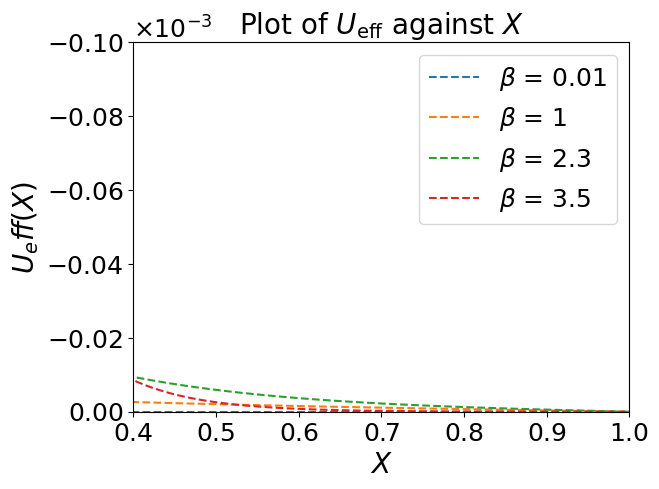

In [40]:
# Plot of $U_{\mathrm{eff}}$ against $X$

plt.plot(X, U_eff(X, 5, 0.01, 10), linestyle = "--", label = r"$\beta$ = 0.01")
plt.plot(X, U_eff(X, 5, 1, 10), linestyle = "--", label = r"$\beta$ = 1")
plt.plot(X, U_eff(X, 5, 2.3, 10), linestyle = "--", label = r"$\beta$ = 2.3")
plt.plot(X, U_eff(X, 5, 6, 10), linestyle = "--", label = r"$\beta$ = 3.5")
plt.title(r"Plot of $U_{\mathrm{eff}}$ against $X$")
plt.xlabel(f"$X$")
plt.xlim(0.4, 1)
plt.ylim(0, -0.0001)
plt.legend()
plt.ylabel(f"$U_eff(X)$")
plt.ticklabel_format(
    axis="y",
    style="sci",
    scilimits=(-3, -3)
)
plt.show()

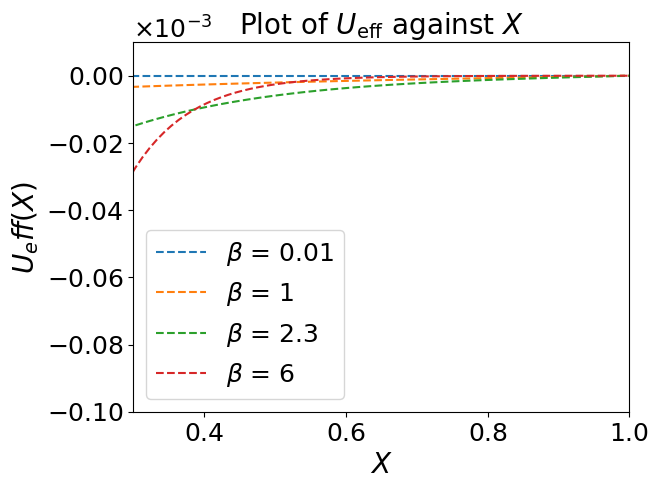

In [41]:
# Plot of $U_{\mathrm{eff}}$ against $X$

plt.plot(X, U_eff(X, 5, 0.001, 10), linestyle = "--", label = r"$\beta$ = 0.01")
plt.plot(X, U_eff(X, 5, 1, 10), linestyle = "--", label = r"$\beta$ = 1")
plt.plot(X, U_eff(X, 5, 2.3, 10), linestyle = "--", label = r"$\beta$ = 2.3")
plt.plot(X, U_eff(X, 5, 6, 10), linestyle = "--", label = r"$\beta$ = 6")
plt.title(r"Plot of $U_{\mathrm{eff}}$ against $X$")
plt.xlabel(f"$X$")
plt.xlim(0.3, 1)
plt.ylim(-0.0001, 0.00001)
plt.legend()
plt.ylabel(f"$U_eff(X)$")
plt.ticklabel_format(
    axis="y",
    style="sci",
    scilimits=(-3, -3)
)
plt.show()

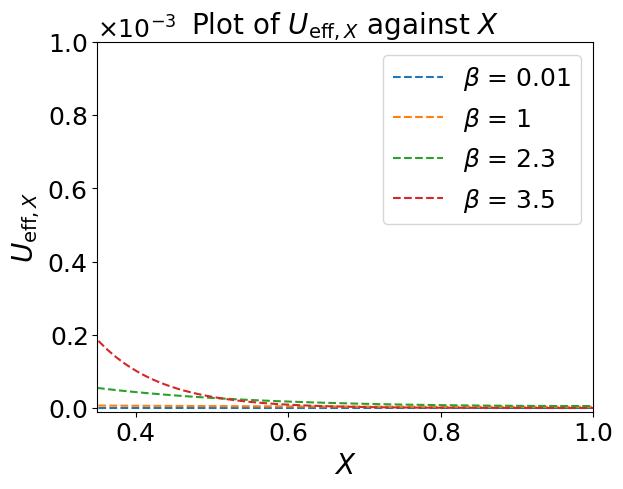

In [42]:
# Plot of $U_{\mathrm{eff},X}$ against $X$

plt.plot(X, U_eff_X(X, 5, 0.01, 10), linestyle = "--", label = r"$\beta$ = 0.01")
plt.plot(X, U_eff_X(X, 5, 1, 10), linestyle = "--", label = r"$\beta$ = 1")
plt.plot(X, U_eff_X(X, 5, 2.3, 10), linestyle = "--", label = r"$\beta$ = 2.3")
plt.plot(X, U_eff_X(X, 5, 6, 10), linestyle = "--", label = r"$\beta$ = 3.5")
plt.title(r"Plot of $U_{\mathrm{eff},X}$ against $X$")
plt.xlabel(f"$X$")
plt.xlim(0.35, 1)
plt.ylim(-0.00001, 0.001)
plt.legend()
plt.ylabel(r"$U_{\mathrm{eff},X}$")
plt.ticklabel_format(
    axis="y",
    style="sci",
    scilimits=(-3, -3)
)
plt.show()

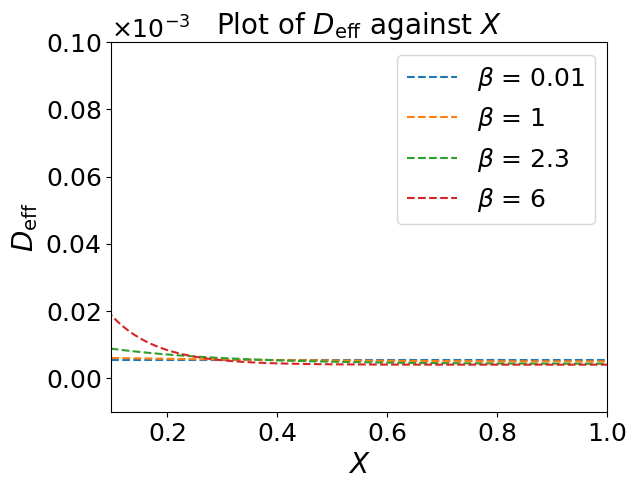

In [43]:
# Plot of $D_{\mathrm{eff}}$ against $X$

plt.plot(X, D_eff(X, 5, 0.001, 10), linestyle = "--", label = r"$\beta$ = 0.01")
plt.plot(X, D_eff(X, 5, 1, 10), linestyle = "--", label = r"$\beta$ = 1")
plt.plot(X, D_eff(X, 5, 2.3, 10), linestyle = "--", label = r"$\beta$ = 2.3")
plt.plot(X, D_eff(X, 5, 6, 10), linestyle = "--", label = r"$\beta$ = 6")
plt.title(r"Plot of $D_{\mathrm{eff}}$ against $X$")
plt.xlabel(f"$X$")
plt.xlim(0.1, 1)
plt.ylim(-0.00001, 0.0001)
plt.legend()
plt.ylabel(r"$D_{\mathrm{eff}}$")
plt.ticklabel_format(
    axis="y",
    style="sci",
    scilimits=(-3, -3)
)
plt.show()

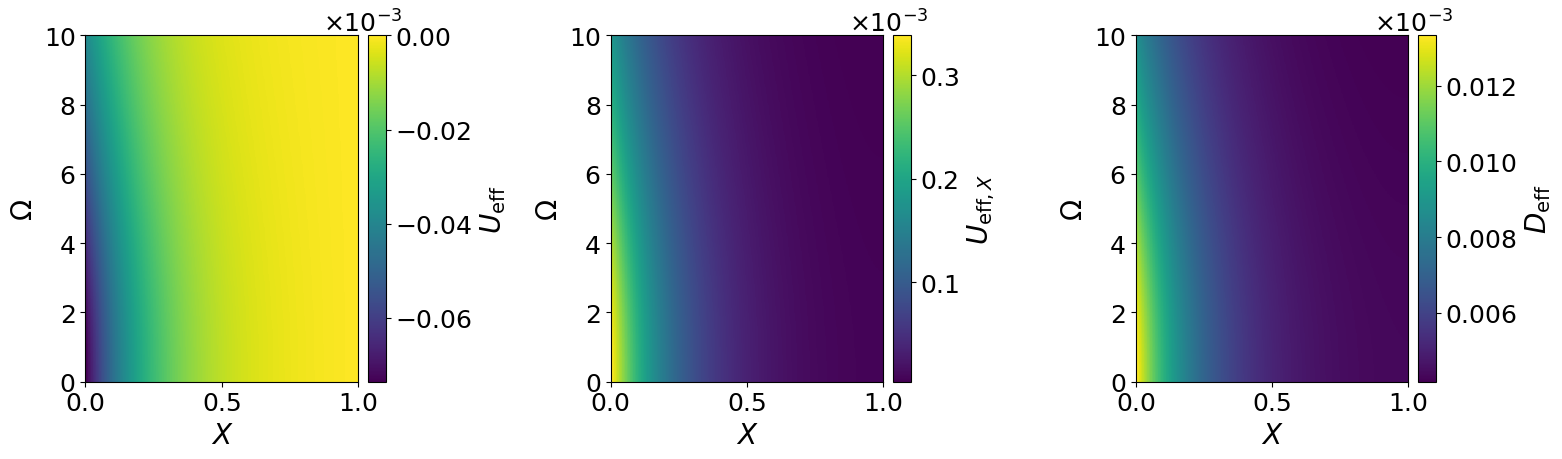

In [45]:
# Effective velocity, effective velocity gradient and effective diffusicity 

# Define linespcaes, grid and discretised values of function
Omega_values = np.linspace(0.01, 10, 100)
X = np.linspace(0, 1, 100)

X_grid, Omega_grid = np.meshgrid(X, Omega_values)

U_eff_values = U_eff(X_grid, Omega_grid, 2.3, 10)
UeffX_values = U_eff_X(X_grid, Omega_grid, 2.3, 10)
Deff_values = D_eff(X_grid, Omega_grid, 2.3, 10)


# Preapre figure
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ------------------------------------------------------------------
# 1. U_eff
# ------------------------------------------------------------------
im1 = axes[0].imshow(
    U_eff_values,
    extent=[0, 1, 0, 10],
    origin="lower",
    aspect="auto",
)

cbar1 = plt.colorbar(im1, ax=axes[0], pad=0.03)
cbar1.set_label(r"$U_\mathrm{eff}$")
formatter1 = ScalarFormatter(useMathText=True)
formatter1.set_scientific(True)
formatter1.set_powerlimits((-3, -3))
cbar1.formatter = formatter1
cbar1.update_ticks()

# move the x10^-3 text
offset1 = cbar1.ax.yaxis.get_offset_text()
offset1.set_y(1.02)
offset1.set_x(2.0)

axes[0].set_xlabel(r"$X$")
axes[0].set_ylabel(r"$\Omega$")
#axes[0].set_title(r"$U_\mathrm{eff}$ with respect to $X$ and $\Omega$", pad=23)

# ------------------------------------------------------------------
# 2. U_eff_X
# ------------------------------------------------------------------
im2 = axes[1].imshow(
    UeffX_values,
    extent=[0, 1, 0, 10],
    origin="lower",
    aspect="auto",
)

cbar2 = plt.colorbar(im2, ax=axes[1], pad=0.03)
cbar2.set_label(r"$U_{\mathrm{eff},X}$")
formatter2 = ScalarFormatter(useMathText=True)
formatter2.set_scientific(True)
formatter2.set_powerlimits((-3, -3))
cbar2.formatter = formatter2
cbar2.update_ticks()

offset2 = cbar2.ax.yaxis.get_offset_text()
offset2.set_y(1.02)
offset2.set_x(2.0)

axes[1].set_xlabel(r"$X$")
axes[1].set_ylabel(r"$\Omega$")
#axes[1].set_title(r"$U_{\mathrm{eff},X}$ with respect to $X$ and $\Omega$", pad=23)

# ------------------------------------------------------------------
# 3. D_eff
# ------------------------------------------------------------------
im3 = axes[2].imshow(
    Deff_values,
    extent=[0, 1, 0, 10],
    origin="lower",
    aspect="auto",
)

cbar3 = plt.colorbar(im3, ax=axes[2], pad=0.03)
cbar3.set_label(r"$D_{\mathrm{eff}}$")
formatter3 = ScalarFormatter(useMathText=True)
formatter3.set_scientific(True)
formatter3.set_powerlimits((-3, -3))
cbar3.formatter = formatter3
cbar3.update_ticks()

offset3 = cbar3.ax.yaxis.get_offset_text()
offset3.set_y(1.02)
offset3.set_x(2.0)

axes[2].set_xlabel(r"$X$")
axes[2].set_ylabel(r"$\Omega$")
#axes[2].set_title(r"$D_{\mathrm{eff}}$ with respect to $X$ and $\Omega$", pad=23)


# Save anf Display figure
plt.tight_layout()
fig.savefig(
    "Oscillatory_coeff_beta2.3.svg",
    bbox_inches="tight"
)

plt.show()

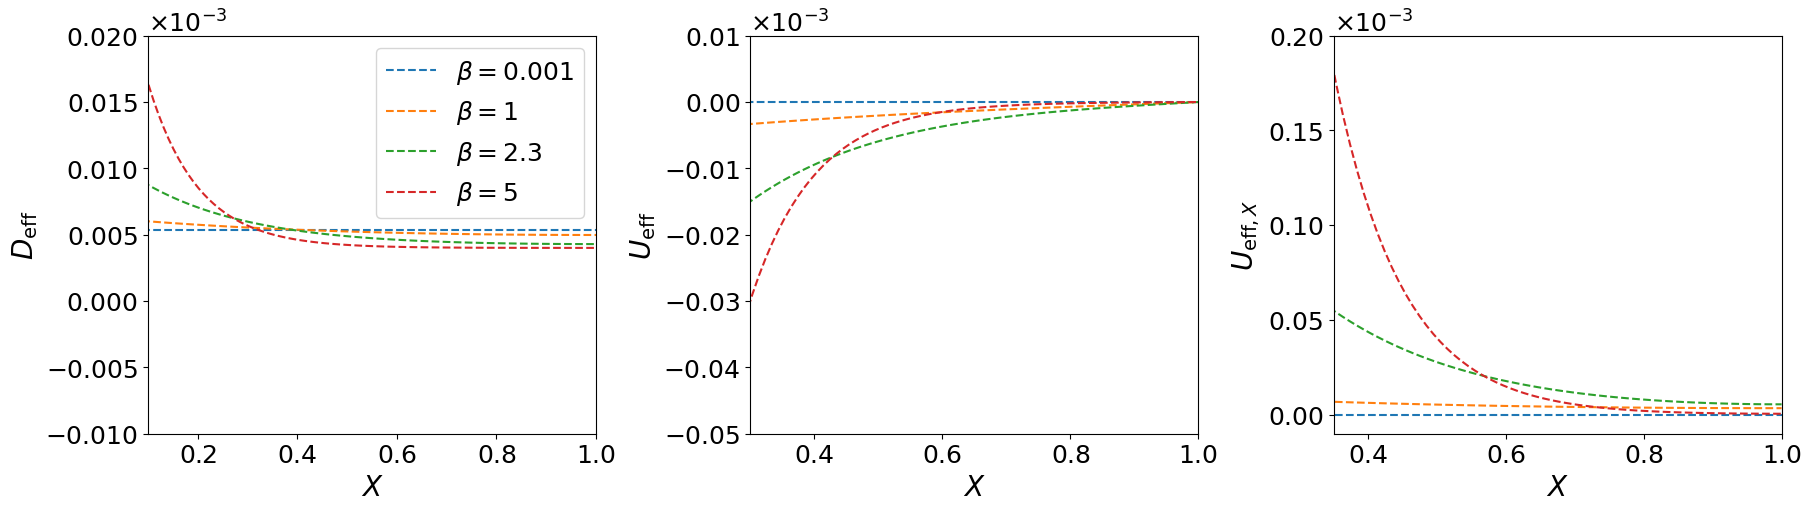

In [50]:
# Plots of effective transport coefficients for moderate frequency Omega = 5 and various beta

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

# ------------------------------------------------------------------
# (a) Effective diffusivity
# ------------------------------------------------------------------
axes[0].plot(
    X, D_eff(X, 5, 0.001, 10),
    linestyle="--",
    label=r"$\beta=0.001$"
)
axes[0].plot(
    X, D_eff(X, 5, 1, 10),
    linestyle="--",
    label=r"$\beta=1$"
)
axes[0].plot(
    X, D_eff(X, 5, 2.3, 10),
    linestyle="--",
    label=r"$\beta=2.3$"
)
axes[0].plot(
    X, D_eff(X, 5, 5, 10),
    linestyle="--",
    label=r"$\beta=5$"
)

#axes[0].set_title(r"$D_{\mathrm{eff}}$ against $X$")
axes[0].set_xlabel(r"$X$")
axes[0].set_ylabel(r"$D_{\mathrm{eff}}$")
axes[0].set_xlim(0.1, 1)
axes[0].set_ylim(-0.00001, 0.00002)
axes[0].legend()
axes[0].ticklabel_format(
    axis="y",
    style="sci",
    scilimits=(-3, -3)
)

# ------------------------------------------------------------------
# (b) Effective velocity
# ------------------------------------------------------------------
axes[1].plot(
    X, U_eff(X, 5, 0.001, 10),
    linestyle="--",
    label=r"$\beta=0.001$"
)
axes[1].plot(
    X, U_eff(X, 5, 1, 10),
    linestyle="--",
    label=r"$\beta=1$"
)
axes[1].plot(
    X, U_eff(X, 5, 2.3, 10),
    linestyle="--",
    label=r"$\beta=2.3$"
)
axes[1].plot(
    X, U_eff(X, 5, 5, 10),
    linestyle="--",
    label=r"$\beta=5$"
)

#axes[1].set_title(r"$U_{\mathrm{eff}}$ against $X$")
axes[1].set_xlabel(r"$X$")
axes[1].set_ylabel(r"$U_{\mathrm{eff}}$")
axes[1].set_xlim(0.3, 1)
axes[1].set_ylim(-0.00005, 0.00001)
axes[1].ticklabel_format(
    axis="y",
    style="sci",
    scilimits=(-3, -3)
)

# ------------------------------------------------------------------
# (c) Effective-velocity derivative
# ------------------------------------------------------------------
axes[2].plot(
    X, U_eff_X(X, 5, 0.01, 10),
    linestyle="--",
    label=r"$\beta=0.01$"
)
axes[2].plot(
    X, U_eff_X(X, 5, 1, 10),
    linestyle="--",
    label=r"$\beta=1$"
)
axes[2].plot(
    X, U_eff_X(X, 5, 2.3, 10),
    linestyle="--",
    label=r"$\beta=2.3$"
)
axes[2].plot(
    X, U_eff_X(X, 5, 5, 10),
    linestyle="--",
    label=r"$\beta=5$"
)

#axes[2].set_title(r"$U_{\mathrm{eff},X}$ against $X$")
axes[2].set_xlabel(r"$X$")
axes[2].set_ylabel(r"$U_{\mathrm{eff},X}$")
axes[2].set_xlim(0.35, 1)
axes[2].set_ylim(-0.00001, 0.0002)
axes[2].ticklabel_format(
    axis="y",
    style="sci",
    scilimits=(-3, -3)
)

# Export as a vector SVG file
fig.savefig(
    "effective_transport_coefficients.svg",
    format="svg",
    bbox_inches="tight"
)

plt.show()

In [51]:
# Define the M value and sigma

def sigma_M(X, Omega, beta, Pe):
    return np.sqrt(D_eff(X, Omega, beta, Pe)/np.abs(U_eff_X(X, Omega, beta, Pe)))

def M(X, Omega, beta, Pe, sigma):
    return (-1)*((D_eff(X,Omega, beta, Pe)/(sigma**2)) + U_eff_X(X, Omega, beta, Pe))

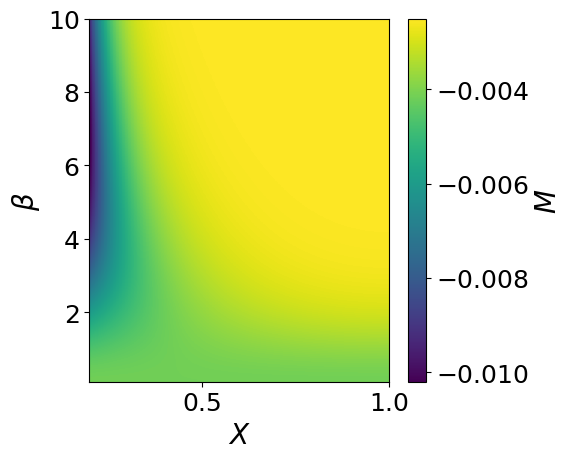

In [57]:
# Plotting M in terms of X and beta

# Define parametes 
sigma_0 = 0.04
Omega = 5
Pe = 14

# Grid in x and beta
X1 = np.linspace(0.2, 1, 100)
X_grid, beta_grid = np.meshgrid(X1, beta_values)

# Calculate M over the grid
M_values = M(X_grid, Omega, beta_grid, Pe, sigma_0)

# Create figure
plt.figure(figsize=(6, 5))

# Plot heatmap
im = plt.imshow(
    M_values,
    extent=[
        X1.min(), X1.max(),
        beta_values.min(), beta_values.max()
    ],
    origin="lower",
    aspect="auto",
)

# Plot colourbar 
cbar = plt.colorbar(im)
cbar.set_label(r"$M$")

plt.xlabel(r"$X$")
plt.ylabel(r"$\beta$")

# plt.title(
#     rf"$M$ as a function of $X$ and $\beta$"
#     f"\n$\Omega={Omega}$, $\operatorname{{Pe}}={Pe}$, "
#     rf"$\sigma_0={sigma_0}$"
# )

plt.tight_layout()

plt.savefig(
    "M_X_beta.svg",
    bbox_inches="tight"
)

plt.show()

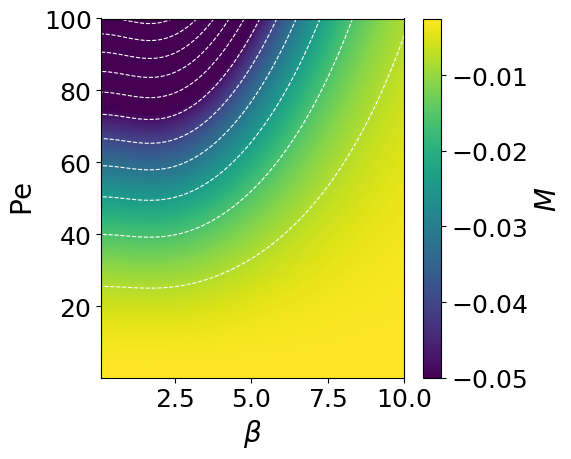

In [67]:
# Plot M for various beta and Pe

from matplotlib.colors import TwoSlopeNorm

# Create linespaces 
beta_values = np.linspace(0.1, 10, 400)
Pe_values = np.linspace(0.1, 100.0, 500)

# Create grid
beta_grid, Pe_grid = np.meshgrid(beta_values, Pe_values)

# Define initial parameters
X_0 = 0.4
sigma_0 = 0.04
Omega = 5

# Discretize M values
M_values = M(X_0, Omega, beta_grid, Pe_grid, sigma_0)

# Plot figure
plt.figure(figsize=(6, 5))

# Plot heatmap
im = plt.imshow(
    M_values,
    extent=[
        beta_values.min(), beta_values.max(),
        Pe_values.min(), Pe_values.max()
    ],
    origin="lower",
    aspect="auto",
    vmin = -0.05
)

# Contour lines for equal values of M
contours = plt.contour(
    beta_values,
    Pe_values,
    M_values,
    levels=10,          # number of contour levels
    colors="white",
    linewidths=0.8
)
plt.contour(
    beta_values,
    Pe_values,
    M_values,
    levels=[0],
    colors="black",
    linewidths=2
)

# Add colourbar
cbar = plt.colorbar(im)
cbar.set_label(r"$M$")

plt.xlabel(r"$\beta$")
plt.ylabel(r"$\operatorname{Pe}$")

# plt.title(
#     rf"$M$ as a function of $\beta$ and $\operatorname{{Pe}}$"
#     f"\n$X_0={X_0}$, $\sigma_0={sigma_0}$"
# )

plt.tight_layout()
plt.savefig(
    f"M04004.svg",
    bbox_inches="tight"
)
plt.show()